In [38]:
# ==============================
# Import Required Libraries
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [39]:
# ==============================
# Load Dataset
# ==============================

df = pd.read_csv("heart.csv")

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA

In [40]:
# ==============================
# Check Dataset Dimensions
# ==============================

df.shape

(918, 12)

In [41]:
# ==============================
# Dataset Information
# ==============================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [42]:
# ==============================
# Statistical Summary
# ==============================

df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [43]:
# ==============================
# Check for Duplicate Records
# ==============================

df.duplicated().sum()

np.int64(0)

In [44]:
# ==============================
# Display Column Names
# ==============================

df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [45]:
# ==============================
# Check for Missing Values
# ==============================

df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

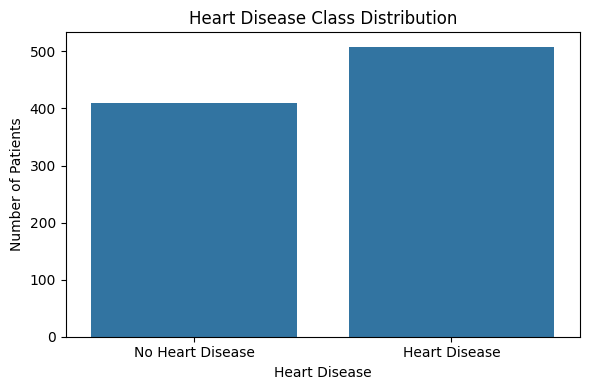

HeartDisease
1    55.34
0    44.66
Name: proportion, dtype: float64

In [46]:
# ==============================
# Heart Disease Class Distribution
# ==============================

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="HeartDisease")

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])

plt.tight_layout()
plt.show()

df["HeartDisease"].value_counts(normalize=True).mul(100).round(2)

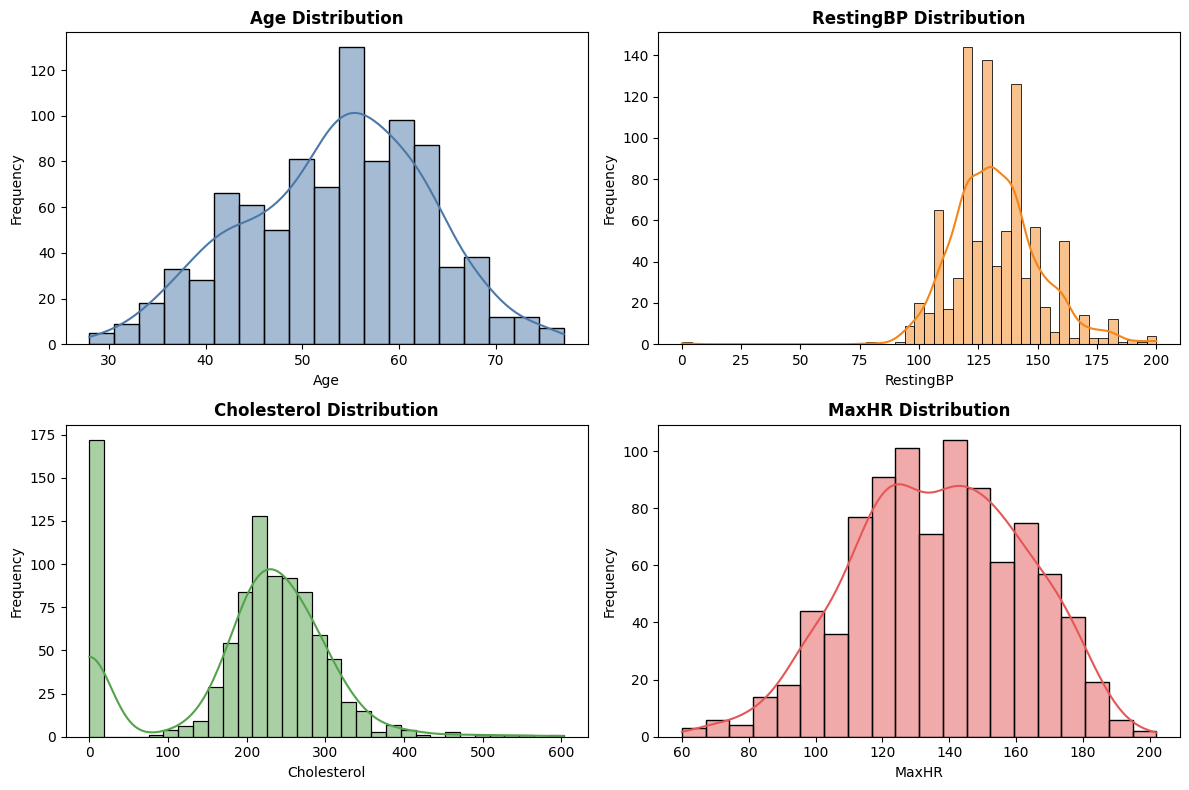

In [47]:
# ==============================
# Distribution of Numerical Features
# ==============================

def plot_distribution(feature, position, color):
    plt.subplot(2, 2, position)

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        color=color
    )

    plt.title(f"{feature} Distribution", fontsize=12, fontweight="bold")
    plt.xlabel(feature)
    plt.ylabel("Frequency")


plt.figure(figsize=(12, 8))

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

features = ["Age", "RestingBP", "Cholesterol", "MaxHR"]

for i, (feature, color) in enumerate(zip(features, colors), 1):
    plot_distribution(feature, i, color)

plt.tight_layout()
plt.show()

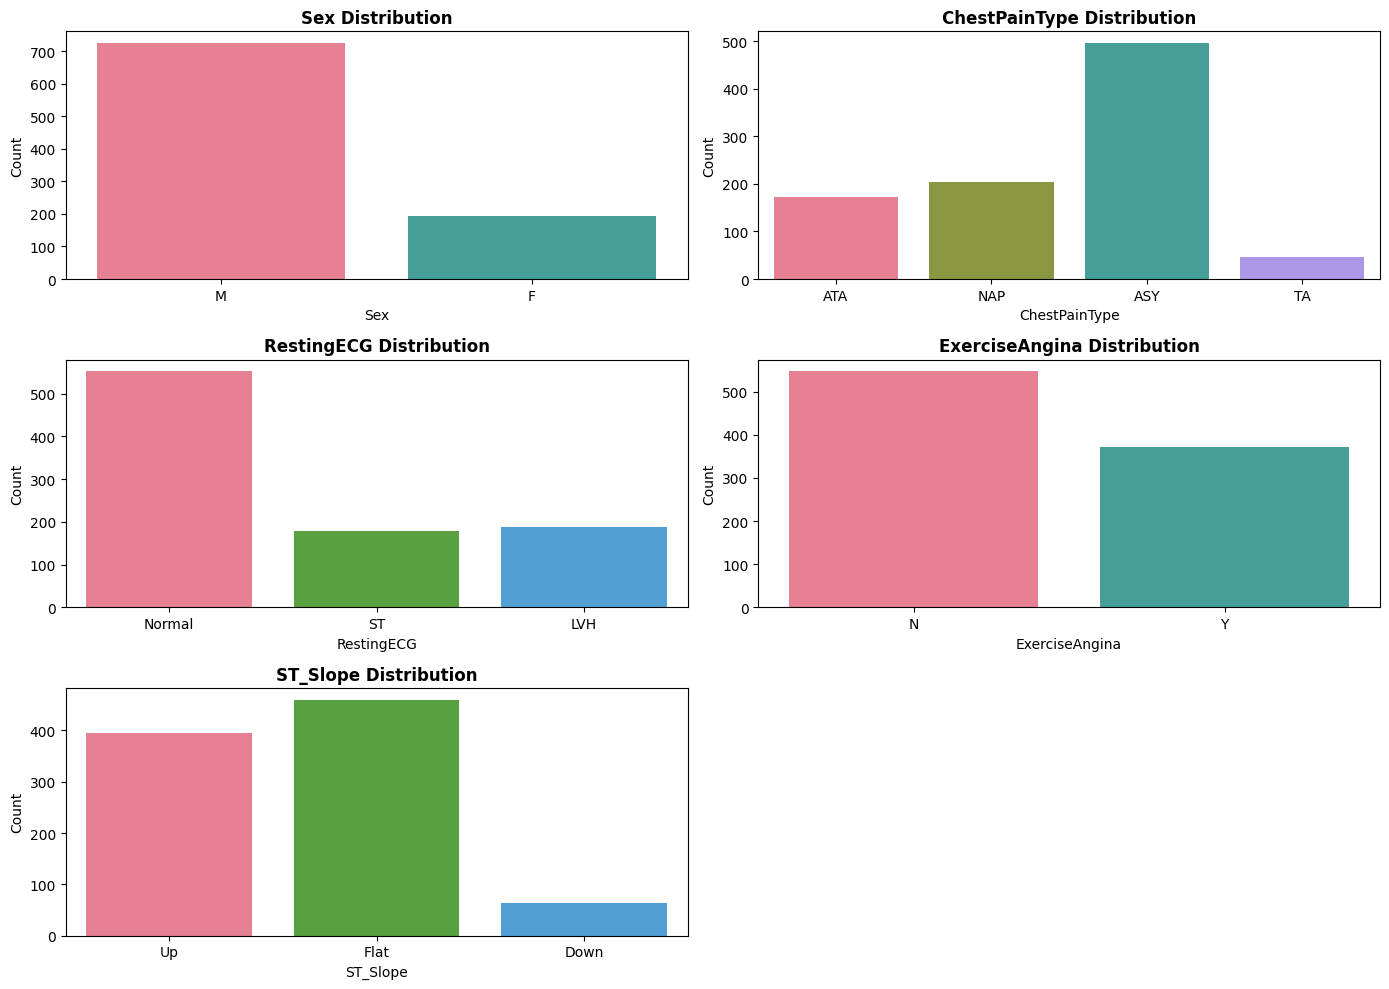

In [48]:
# ==============================
# Categorical Feature Distribution
# ==============================

categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

plt.figure(figsize=(14, 10))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)

    sns.countplot(
        data=df,
        x=feature,
        palette="husl"
    )

    plt.title(f"{feature} Distribution", fontsize=12, fontweight="bold")
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

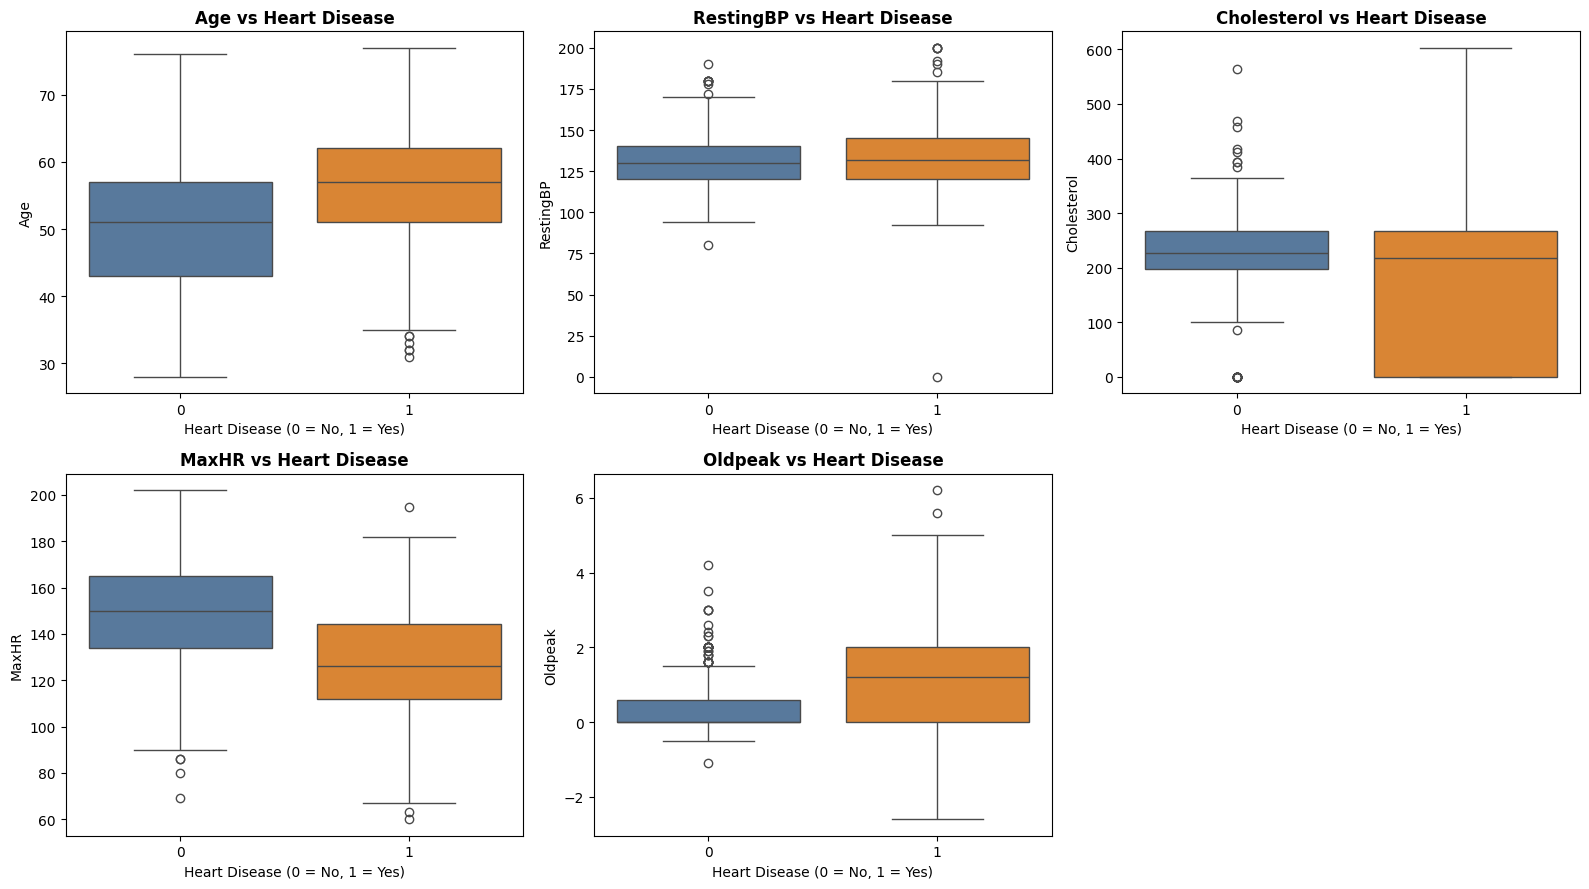

In [49]:
# ==========================================
# Numerical Features vs Heart Disease
# ==========================================

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = ["#4C78A8", "#F58518"]

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        data=df,
        x="HeartDisease",
        y=feature,
        hue="HeartDisease",
        palette=colors,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} vs Heart Disease",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel("Heart Disease (0 = No, 1 = Yes)")
    axes[i].set_ylabel(feature)

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

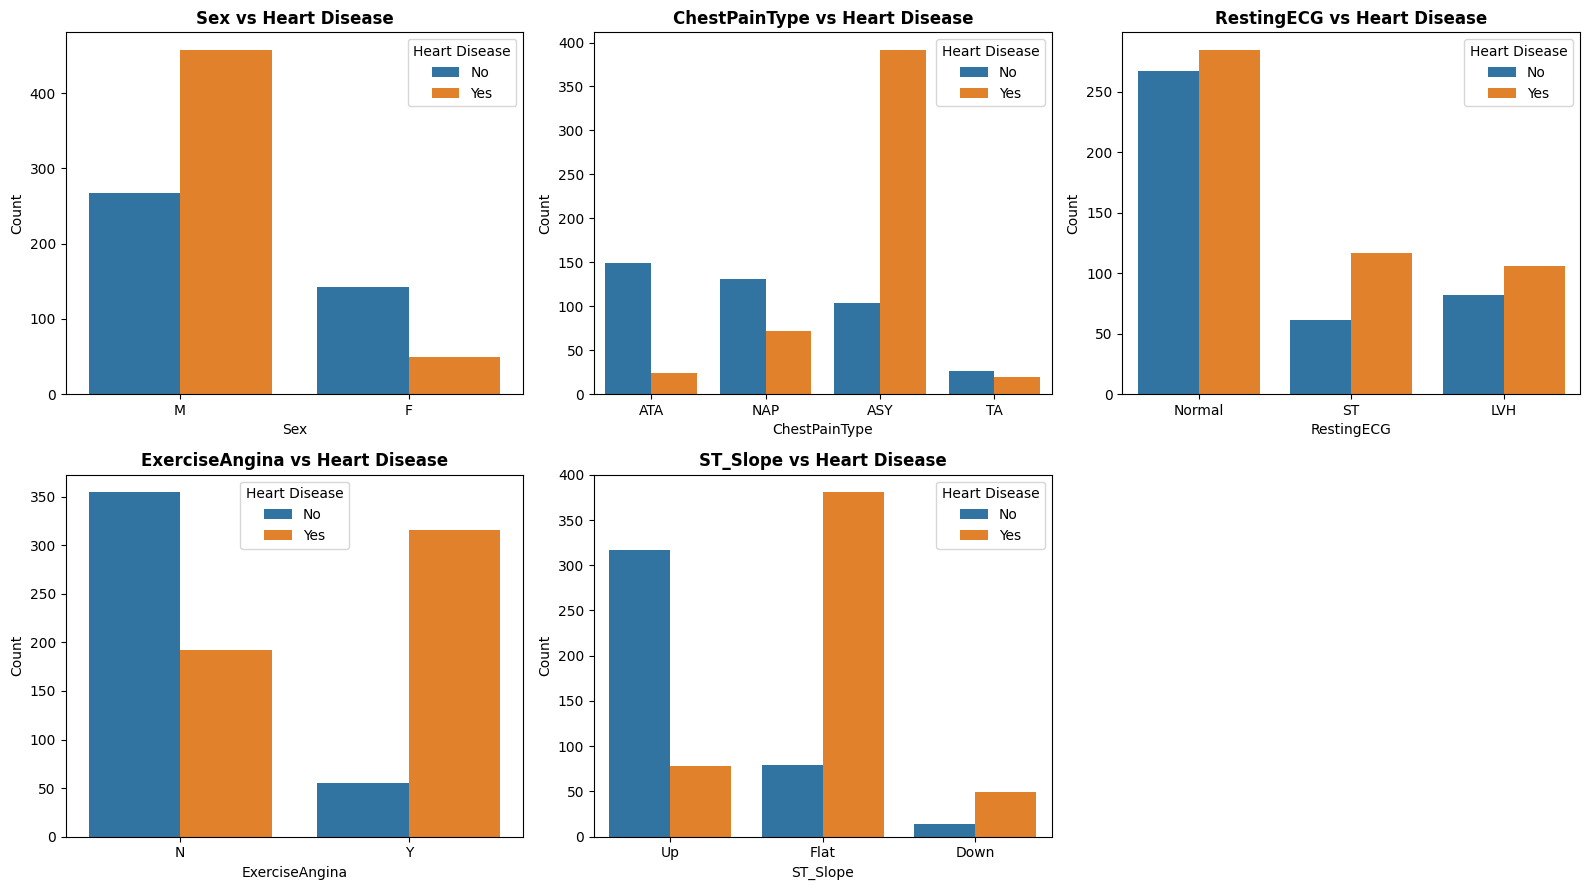

In [50]:
# ==========================================
# Categorical Features vs Heart Disease
# ==========================================

categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    sns.countplot(
        data=df,
        x=feature,
        hue="HeartDisease",
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} vs Heart Disease",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

    axes[i].legend(
        title="Heart Disease",
        labels=["No", "Yes"]
    )

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

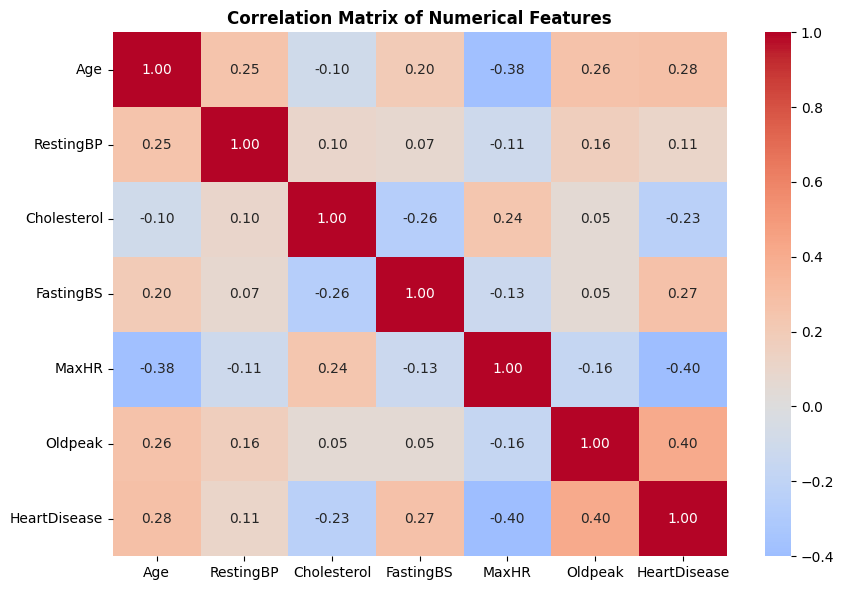

In [51]:
# ==========================================
# Numerical Features Correlation
# ==========================================

numeric_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features", fontweight="bold")
plt.tight_layout()
plt.show()

In [52]:
# Check zero values in numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

zero_counts = (df[numeric_cols] == 0).sum().sort_values(ascending=False)

zero_counts

FastingBS       704
HeartDisease    410
Oldpeak         368
Cholesterol     172
RestingBP         1
Age               0
MaxHR             0
dtype: int64

In [53]:
# Replace invalid Cholesterol = 0 with median of valid values
ch_median = df.loc[df['Cholesterol'] > 0, 'Cholesterol'].median()

df['Cholesterol'] = df['Cholesterol'].replace(0, ch_median)

print("Cholesterol median used:", ch_median)
print("Remaining zero values:", (df['Cholesterol'] == 0).sum())

Cholesterol median used: 237.0
Remaining zero values: 0


In [54]:
# Replace invalid RestingBP value (0) with median of valid values
rbp_median = df.loc[df['RestingBP'] > 0, 'RestingBP'].median()

df['RestingBP'] = df['RestingBP'].replace(0, rbp_median)

print("RestingBP median used:", rbp_median)
print("Remaining zero values:", (df['RestingBP'] == 0).sum())

RestingBP median used: 130.0
Remaining zero values: 0


In [55]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Data Prepocessing and Cleaning

In [61]:
# ==============================
# Separate Features and Target
# ==============================

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (918, 11)
Target shape: (918,)


In [62]:
# ==============================
# Train-Test Split
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (734, 11)
X_test: (184, 11)
y_train: (734,)
y_test: (184,)


In [63]:
# ==============================
# Define Feature Types
# ==============================

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

In [64]:
# ==============================
# Preprocessing Pipeline
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Feature Extraction

In [67]:
from scipy.stats import pearsonr, chi2_contingency

# Numerical features - Pearson correlation
numeric_features = [
    "Age", "RestingBP", "Cholesterol",
    "FastingBS", "MaxHR", "Oldpeak"
]

pearson_results = {
    col: round(pearsonr(df[col], df["HeartDisease"])[0], 3)
    for col in numeric_features
}

pearson_df = pd.DataFrame(
    pearson_results.items(),
    columns=["Feature", "Pearson Correlation"]
).sort_values("Pearson Correlation", ascending=False)


# Categorical features - Chi-Square test
categorical_features = [
    "Sex", "ChestPainType", "RestingECG",
    "ExerciseAngina", "ST_Slope"
]

chi2_results = {}

for col in categorical_features:
    table = pd.crosstab(df[col], df["HeartDisease"])
    chi2, p, _, _ = chi2_contingency(table)

    chi2_results[col] = {
        "Chi2": round(chi2, 3),
        "p-value": round(p, 5),
        "Result": "Significant" if p < 0.05 else "Not Significant"
    }

chi2_df = pd.DataFrame(chi2_results).T.sort_values("p-value")

print("Numerical Features - Pearson Correlation")
display(pearson_df)

print("\nCategorical Features - Chi-Square Test")
display(chi2_df)

Numerical Features - Pearson Correlation


,Feature,Pearson Correlation
5,Oldpeak,0.404
0,Age,0.282
3,FastingBS,0.267
1,RestingBP,0.118
2,Cholesterol,0.076
4,MaxHR,-0.400



Categorical Features - Chi-Square Test


,Chi2,p-value,Result
Sex,84.145,0.0,Significant
ChestPainType,268.067,0.0,Significant
ExerciseAngina,222.259,0.0,Significant
ST_Slope,355.918,0.0,Significant
RestingECG,10.931,0.00423,Significant


# MODEL

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": SVC(
        probability=True,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.875000,0.862385,0.921569,0.890995,0.942013
1,Logistic Regression,0.885870,0.885714,0.911765,0.898551,0.933046
2,Random Forest,0.880435,0.877358,0.911765,0.894231,0.927786
3,KNN,0.864130,0.881188,0.872549,0.876847,0.926889
4,Gradient Boosting,0.880435,0.892157,0.892157,0.892157,0.918341
5,Decision Tree,0.804348,0.823529,0.823529,0.823529,0.802009


In [75]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models_cv = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "SVM": SVC(
        probability=True,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models_cv.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

cv_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.8606,0.8615,0.8938,0.8768,0.9229
1,Gradient Boosting,0.8617,0.8624,0.8958,0.8779,0.9227
2,Logistic Regression,0.8606,0.8655,0.8880,0.8756,0.9211
3,SVM,0.8638,0.8545,0.9115,0.8814,0.9198


In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ==========================================
# Hyperparameter Tuning
# ==========================================

param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear", "lbfgs"]
    },

    "SVM": {
        "model__C": [0.1, 1, 10, 100],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 5],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    }
}

In [77]:
tuned_models = {}
tuning_results = []

for name, params in param_grids.items():

    if name == "Logistic Regression":
        model = LogisticRegression(
            max_iter=2000,
            random_state=42
        )

    elif name == "SVM":
        model = SVC(
            probability=True,
            random_state=42
        )

    elif name == "Random Forest":
        model = RandomForestClassifier(
            random_state=42
        )

    elif name == "Gradient Boosting":
        model = GradientBoostingClassifier(
            random_state=42
        )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X, y)

    tuned_models[name] = grid_search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best ROC-AUC": grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df.sort_values(
    "Best ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Best ROC-AUC,Best Parameters
0,Gradient Boosting,0.928402,"{'model__learning_rate': 0.05, 'model__max_dep..."
1,Random Forest,0.926341,"{'model__max_depth': 10, 'model__min_samples_l..."
2,SVM,0.923471,"{'model__C': 1, 'model__gamma': 'auto', 'model..."
3,Logistic Regression,0.922421,"{'model__C': 0.1, 'model__solver': 'lbfgs'}"


In [78]:
for name, model in tuned_models.items():
    print(f"\n{name}")
    print("-" * 40)
    print(model.named_steps["model"].get_params())


Logistic Regression
----------------------------------------
{'C': 0.1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 2000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

SVM
----------------------------------------
{'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'auto', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Random Forest
----------------------------------------
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, '

In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

final_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9239,0.9231,0.9412,0.9320,0.9729
1,SVM,0.9185,0.9223,0.9314,0.9268,0.9619
2,Gradient Boosting,0.8967,0.8879,0.9314,0.9091,0.9579
3,Logistic Regression,0.8859,0.8857,0.9118,0.8986,0.9436


<Figure size 600x500 with 0 Axes>

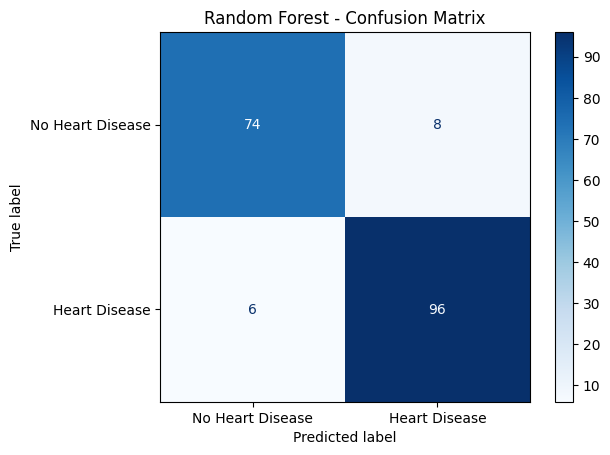

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Final Random Forest predictions
final_rf = tuned_models["Random Forest"]

y_pred_rf = final_rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Random Forest - Confusion Matrix")
plt.show()

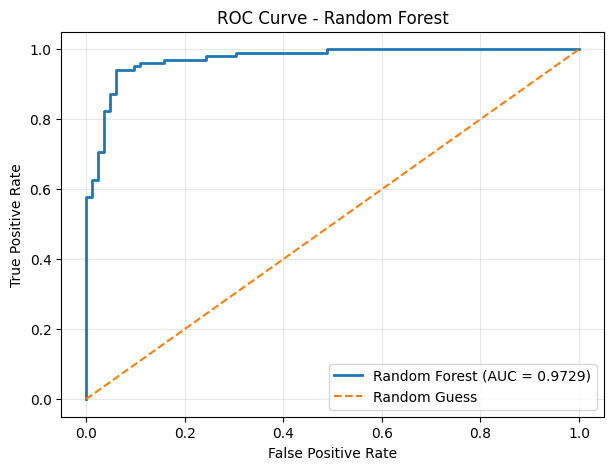

ROC-AUC Score: 0.9729


In [81]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions for positive class
y_prob_rf = final_rf.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# AUC
auc_score = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

In [82]:
# Get the trained Random Forest model
rf_model = final_rf.named_steps["model"]

# Get feature names after preprocessing
feature_names = final_rf.named_steps["preprocessor"].get_feature_names_out()

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
19,cat__ST_Slope_Up,0.197560
18,cat__ST_Slope_Flat,0.129632
8,cat__ChestPainType_ASY,0.101761
5,num__Oldpeak,0.093653
15,cat__ExerciseAngina_N,0.083341
16,cat__ExerciseAngina_Y,0.067871
4,num__MaxHR,0.062280
0,num__Age,0.046731
2,num__Cholesterol,0.044974
1,num__RestingBP,0.036774


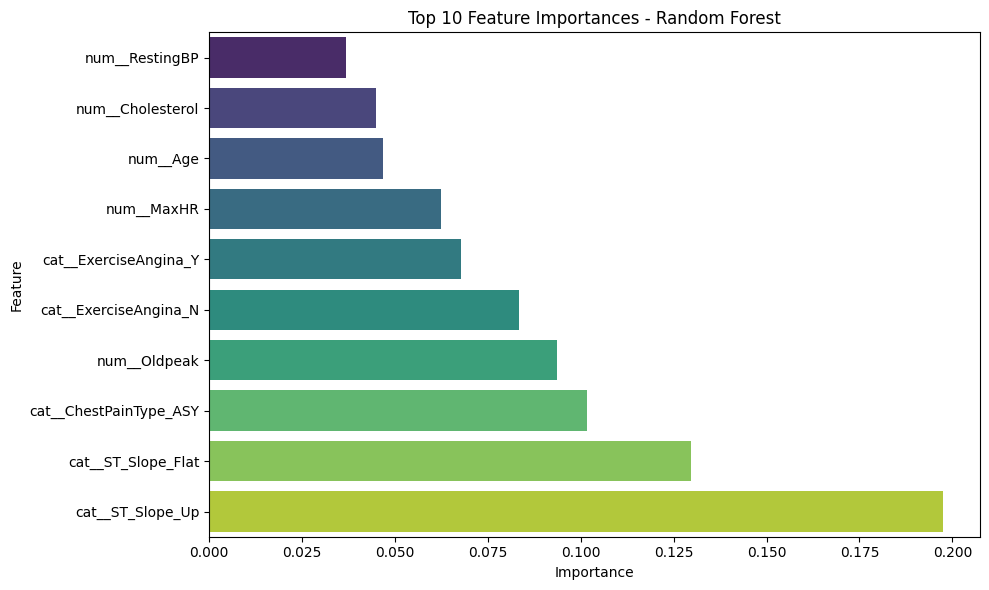

In [83]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [84]:
!pip install shap

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 6.2 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 3.4 MB/s eta 0:00:13
   - -------------------------------------- 1.6/41.9 MB 4.0 MB/s eta 0:00:11
   -- ------------------------------------- 2.6/41.9 MB 4.4 MB/s eta 0:00:09
   --- ------------------------------------ 3.4/41.9 MB 4.3 MB/s eta 0:00:09
   --- ------------------------------------ 3.9/41.9 MB 4.1 MB/s eta 0:00:10
   ---- ----------------------------------- 4.7/41.9 MB 3.8 MB/s eta 0:00:10
   ----- ---------------------------------- 5.5/41.9 MB 3.9 MB/s eta 0:00:10
   ------ --------------------------------- 6.6/41.9 MB 3.9 MB/s eta 0:00:09
   ------ --------------------------------- 7.1/41.9 MB 3.9 MB/s eta 0:00:09
   ------- -------------------------------- 8.1/41.9 MB 3.9 MB/s eta 0:00:09
   -------- 

In [85]:
import shap
import matplotlib.pyplot as plt

In [86]:
rf_model = final_rf.named_steps["model"]
preprocessor = final_rf.named_steps["preprocessor"]

X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_test_transformed.head()

,num__Age,num__RestingBP,num__Cholesterol,num__FastingBS,num__MaxHR,num__Oldpeak,cat__Sex_F,cat__Sex_M,cat__ChestPainType_ASY,cat__ChestPainType_ATA,cat__ChestPainType_NAP,cat__ChestPainType_TA,cat__RestingECG_LVH,cat__RestingECG_Normal,cat__RestingECG_ST,cat__ExerciseAngina_N,cat__ExerciseAngina_Y,cat__ST_Slope_Down,cat__ST_Slope_Flat,cat__ST_Slope_Up
356,-0.796702,-0.975406,-0.116255,-0.551341,-0.935665,0.574711,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
763,0.476173,-0.029929,-0.359828,-0.551341,1.422226,2.169475,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
817,0.688318,-0.419243,0.277208,-0.551341,0.164684,1.794236,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
735,-0.478484,-0.697325,-1.034336,-0.551341,0.086088,1.043759,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
892,-1.539213,0.303769,-0.434773,-0.551341,0.596964,-0.832432,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [92]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP shape:", shap_values.shape)

SHAP shape: (184, 20, 2)


In [88]:
print("X shape:", X_test_transformed.shape)

if isinstance(shap_values, list):
    for i, values in enumerate(shap_values):
        print(f"Class {i} SHAP shape:", values.shape)
else:
    print("SHAP shape:", shap_values.shape)

X shape: (184, 20)
SHAP shape: (184, 20, 2)


SHAP shape: (184, 20)


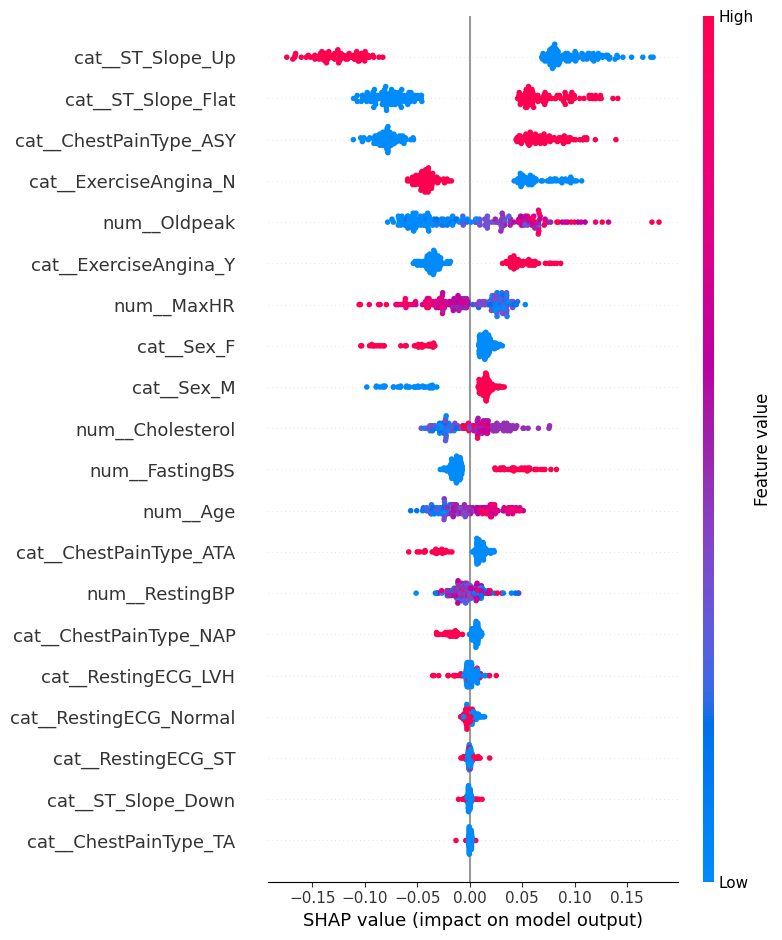

In [93]:
shap_values_class1 = shap_values[:, :, 1]

print("SHAP shape:", shap_values_class1.shape)

shap.summary_plot(
    shap_values_class1,
    X_test_transformed,
    feature_names=feature_names
)

In [94]:
import joblib

joblib.dump(final_rf, "heart_disease_random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [95]:
loaded_model = joblib.load("heart_disease_random_forest.pkl")

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [96]:
sample_prediction = model.predict(X_test.iloc[[0]])
sample_probability = model.predict_proba(X_test.iloc[[0]])[0]

print("Prediction:", sample_prediction[0])
print("Probability:", sample_probability)

Prediction: 1
Probability: [0.0632445 0.9367555]
